## Load Dataset

In [79]:
import pandas as pd
df = pd.read_csv(r"C:\Users\LENOVO\Downloads\advertising_1000_rows.csv")
print(df)

             TV      Radio  Newspaper      Sales
0    112.362036   9.256646  26.170568   8.638895
1    285.214292  27.095047  24.697880  19.073905
2    219.598183  43.647292  90.625458  19.975570
3    179.597545  36.611244  24.954620  13.128805
4     46.805592  40.328057  27.194973  11.737464
..          ...        ...        ...        ...
995   27.474622  32.847758  86.529576  10.686887
996  275.194073  47.830731  15.727321  21.058776
997   41.045589   3.447901  30.978786   5.187470
998  285.071206   2.852736  29.004553  14.670108
999  133.801732  14.109354  87.141403   9.325448

[1000 rows x 4 columns]


In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         1000 non-null   float64
 1   Radio      1000 non-null   float64
 2   Newspaper  1000 non-null   float64
 3   Sales      1000 non-null   float64
dtypes: float64(4)
memory usage: 31.4 KB


In [81]:
df.describe()

,TV,Radio,Newspaper,Sales
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,147.076966,25.350865,50.240573,11.864911
std,87.641209,14.609495,29.067420,5.041751
min,1.389607,0.160913,0.001163,-1.343389
25%,70.791980,12.053714,26.135098,8.095873
50%,149.042213,25.936695,50.061392,11.857404
75%,223.295876,38.023253,75.910353,15.420071
max,299.915302,49.970686,99.782086,25.703344


## Check Missing Values

In [82]:
df.isnull().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

### ***EDA (Exploratory Data Analysis)***

**Correlation Heatmap**

This shows the relationship between variables.

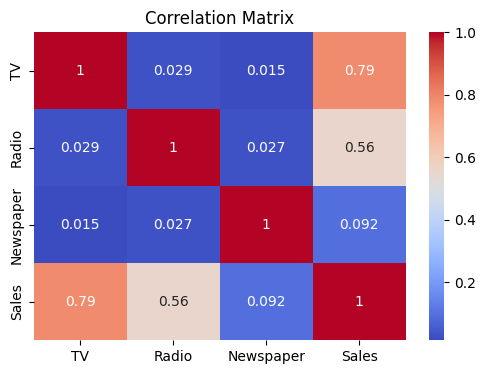

In [83]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

**Insight:**

- TV vs Sales → strong correlation
- Radio vs Sales → moderate correlation
- Newspaper vs Sales → weak correlation

**Pairplot**

This shows relationships between all features.

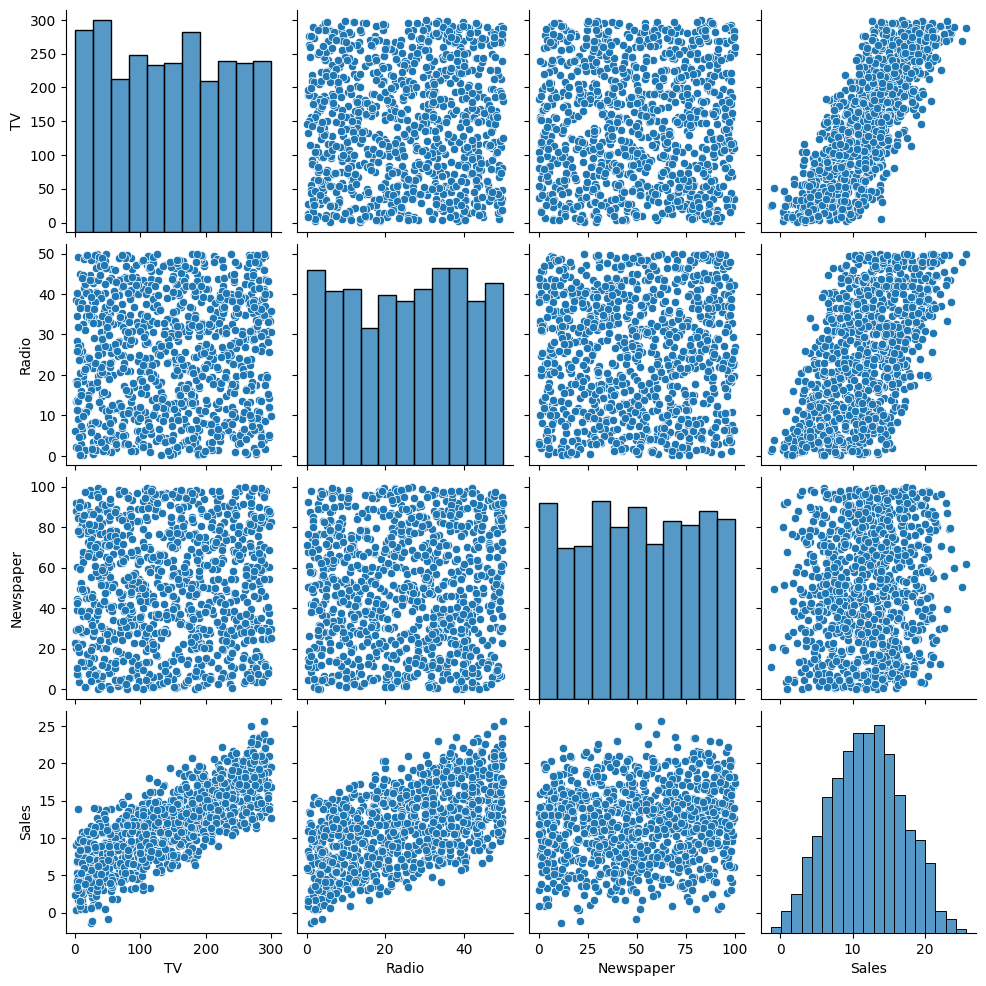

In [84]:
sns.pairplot(df)
plt.show()

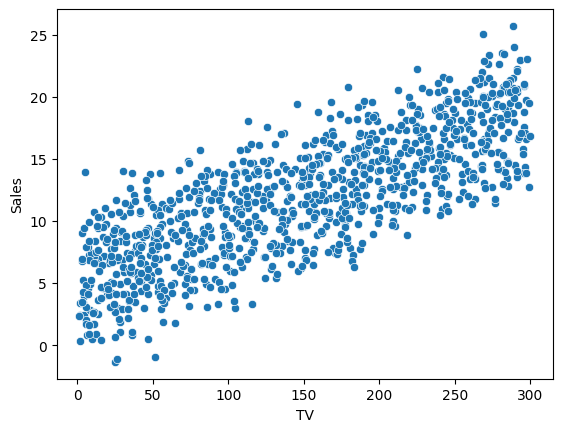

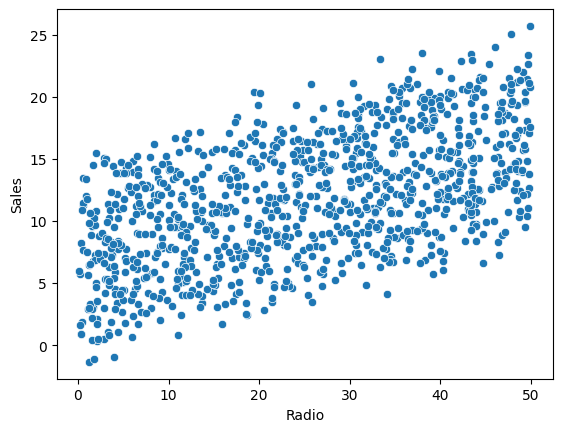

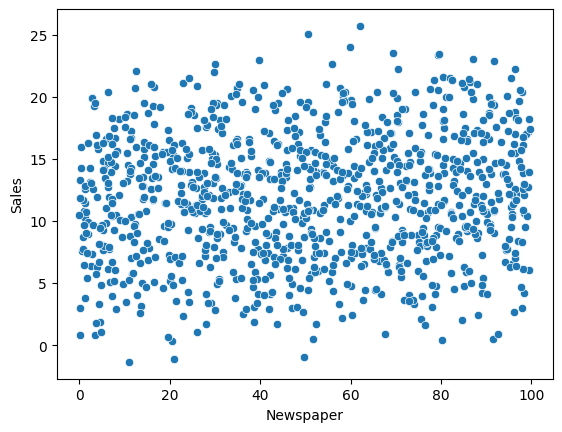

In [85]:
sns.scatterplot(x='TV', y='Sales', data=df)
plt.show()
sns.scatterplot(x='Radio', y='Sales', data=df)
plt.show()
sns.scatterplot(x='Newspaper', y='Sales', data=df)
plt.show()

**Scatter Plot (TV vs Sales)**

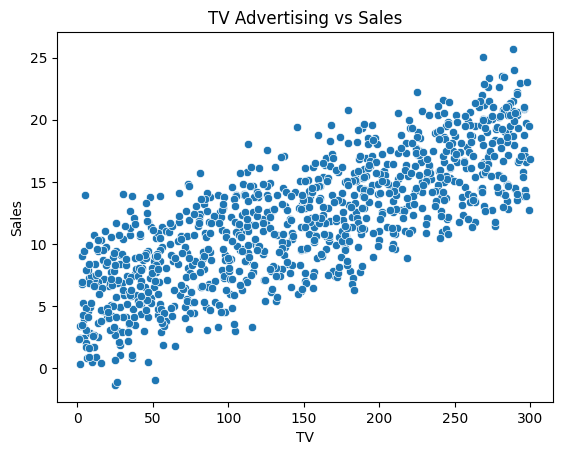

In [86]:
sns.scatterplot(x='TV', y='Sales', data=df)
plt.title("TV Advertising vs Sales")
plt.show()

**Scatter Plot (Radio vs Sales)**

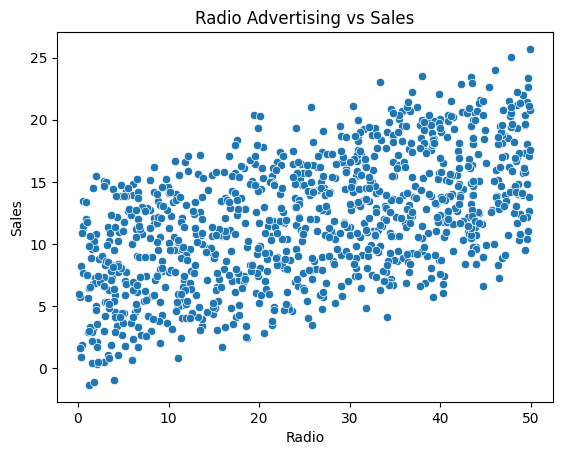

In [87]:
sns.scatterplot(x='Radio', y='Sales', data=df)
plt.title("Radio Advertising vs Sales")
plt.show()

**Box plot**

Outlier Detection

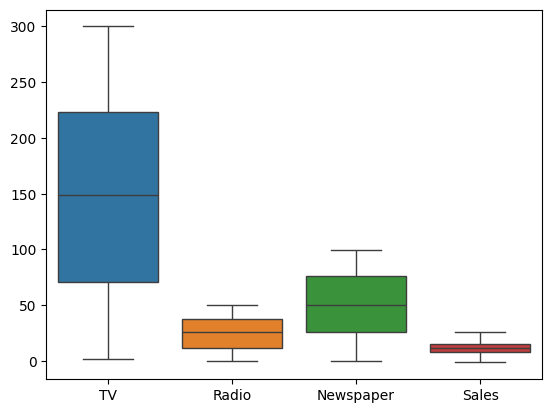

In [88]:
sns.boxplot(data=df)
plt.show()

**Distribution of Sales**

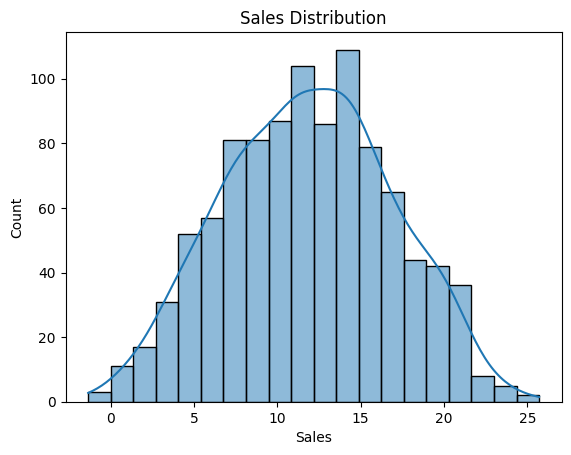

In [89]:
sns.histplot(df['Sales'], bins=20, kde=True)
plt.title("Sales Distribution")
plt.show()

**Regression Plot**

This shows the regression relationship.

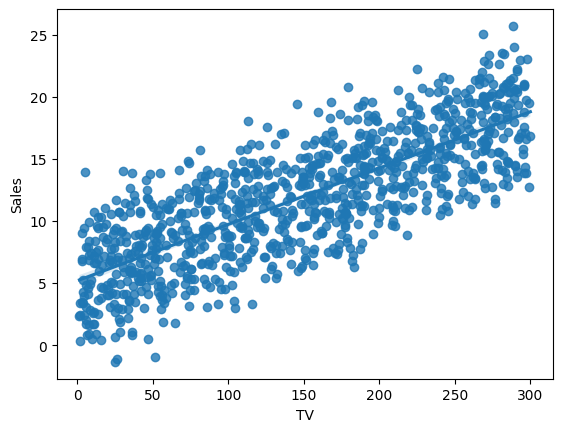

In [90]:
sns.regplot(x='TV', y='Sales', data=df)
plt.show()

### **Key Insights from EDA**

✔ TV advertising has strong impact on sales

✔ Radio has medium impact

✔ Newspaper has very small impact

### Train Test Split,Train Linear Regression Model

In [91]:
X= df[['TV', 'Radio', 'Newspaper']]
y= df['Sales']

print(X)
print(y)

             TV      Radio  Newspaper
0    112.362036   9.256646  26.170568
1    285.214292  27.095047  24.697880
2    219.598183  43.647292  90.625458
3    179.597545  36.611244  24.954620
4     46.805592  40.328057  27.194973
..          ...        ...        ...
995   27.474622  32.847758  86.529576
996  275.194073  47.830731  15.727321
997   41.045589   3.447901  30.978786
998  285.071206   2.852736  29.004553
999  133.801732  14.109354  87.141403

[1000 rows x 3 columns]
0       8.638895
1      19.073905
2      19.975570
3      13.128805
4      11.737464
         ...    
995    10.686887
996    21.058776
997     5.187470
998    14.670108
999     9.325448
Name: Sales, Length: 1000, dtype: float64


In [92]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = GradientBoostingRegressor()
model.fit(X_train, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

### Prediction

In [93]:
y_pred = model.predict(X_test)
y_pred

array([14.06568206, 12.98121985, 14.60943836, 11.24183864, 14.91426378,
       14.97028121,  8.38825243, 12.5277309 ,  7.36393358, 14.72194455,
       19.16413916, 14.825533  , 13.3511849 ,  8.01881294,  7.18582176,
        7.33018402, 17.7915327 ,  7.57137794, 12.43485101,  5.36612938,
       15.60472511, 14.7587335 ,  4.20889211,  7.30658394, 13.56174536,
       13.9884635 , 17.69190396, 15.09975094,  8.93217429, 13.97787747,
       13.15647094, 18.8468157 ,  4.66835876, 21.65729037, 10.66663051,
       19.49204751,  9.20384049, 17.94066283,  0.88489863, 10.42228878,
       12.85491466,  9.05058919,  7.04534451,  4.10668703,  7.76121274,
       18.03446346, 13.00264464,  6.2431257 ,  6.76541109,  7.9890508 ,
       13.0047576 ,  8.70503916, 21.37143152, 12.58079894, 14.01783841,
        8.83095051, 10.64443488,  3.53915347, 10.03535527, 13.68354713,
       13.14850325, 18.42969899,  9.21877108, 13.53123971,  4.03011265,
       11.2987197 , 16.13562764,  3.96426627, 13.60887823, 12.25

### Model Accuracy (R² Score)

In [94]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
print("R² Score:", r2)

R² Score: 0.8871390219273599


### try Better Algorithms

Random Forest Regressor

In [95]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor()
model.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

### Hyperparameter Tuning

In [96]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor

param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid = GridSearchCV(GradientBoostingRegressor(),
param_grid,cv=5,scoring='r2',n_jobs=-1)
grid.fit(X_train, y_train)
best_model = grid.best_estimator_
print("Best Params:", grid.best_params_)

Best Params: {'learning_rate': 0.1, 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}


### Prediction

In [97]:
from sklearn.metrics import r2_score
y_pred = best_model.predict(X_test)

### R2 Score

In [98]:
r2 = r2_score(y_test, y_pred)
print("Final R² Score:", r2)

Final R² Score: 0.8872225789244463


### Remove Outliers

<Axes: ylabel='Sales'>

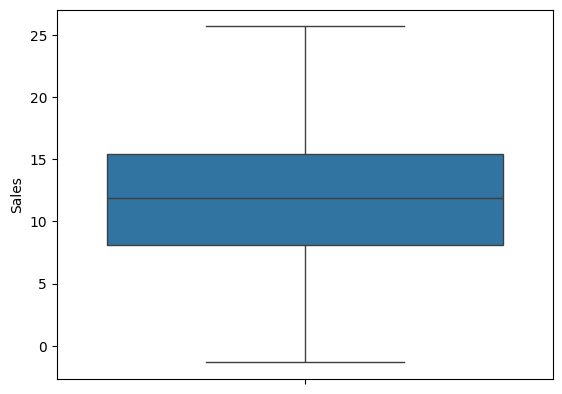

In [99]:
sns.boxplot(df['Sales'])

### ***Save Model***

In [100]:
import pickle
pickle.dump(model,open("advertising_model.pkl","wb"))
pickle.dump(grid,open("advertising_grid.pkl","wb"))